In [5]:
# 0. Colab GPU 확인 및 필요한 라이브러리 설치
# Runtime > Change runtime type > T4 GPU를 먼저 선택한다.

!nvidia-smi
%pip install -q "ultralytics>=8.3.0" scikit-learn

import torch
import ultralytics

print("PyTorch:", torch.__version__)
print("Ultralytics:", ultralytics.__version__)
print("CUDA available:", torch.cuda.is_available())

assert torch.cuda.is_available(), "Colab Runtime을 T4 GPU로 변경하세요."

Fri Jul 17 00:48:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
# 1. 업로드한 Roboflow-4k dataset 압축파일 확인
# 파일 창에서 업로드가 완전히 끝난 후 실행한다.

from pathlib import Path

dataset_archive = Path(
    "/content/roboflow_braille_detection_effdet_data.tar.gz"
)

assert dataset_archive.exists(), f"파일이 없습니다: {dataset_archive}"

print("Dataset file:", dataset_archive)
print(
    "Dataset size:",
    round(dataset_archive.stat().st_size / 1024**2, 1),
    "MB",
)

Dataset file: /content/roboflow_braille_detection_effdet_data.tar.gz
Dataset size: 279.0 MB


In [7]:
# 2. Dataset 압축파일 검사 및 압축 해제
# gzip 손상 여부를 먼저 확인한 후 /content 아래에 압축을 푼다.

%cd /content

!gzip -t /content/roboflow_braille_detection_effdet_data.tar.gz
!tar -xzf /content/roboflow_braille_detection_effdet_data.tar.gz -C /content

!find /content/outputs/roboflow_braille_detection_prepared/effdet_coco/annotations -maxdepth 1 -type f

/content
/content/outputs/roboflow_braille_detection_prepared/effdet_coco/annotations/instances_val2017.json
/content/outputs/roboflow_braille_detection_prepared/effdet_coco/annotations/instances_test2017.json
/content/outputs/roboflow_braille_detection_prepared/effdet_coco/annotations/instances_train2017.json


In [8]:
# 3. COCO annotation을 one-class YOLO 형식으로 변환
# A-Z를 하나의 braille_character 클래스로 합쳐 YOLO는 위치만 검출하게 한다.

import json
import os
import shutil

from collections import defaultdict
from pathlib import Path

coco_root = Path(
    "/content/outputs/"
    "roboflow_braille_detection_prepared/effdet_coco"
)
yolo_root = Path(
    "/content/yolo_braille_one_class"
)

split_config = {
    "train": ("train2017", "instances_train2017.json"),
    "val": ("val2017", "instances_val2017.json"),
    "test": ("test2017", "instances_test2017.json"),
}

conversion_summary = {}

for split, (image_folder, annotation_file) in split_config.items():
    source_image_dir = coco_root / image_folder
    annotation_path = (
        coco_root / "annotations" / annotation_file
    )

    output_image_dir = yolo_root / "images" / split
    output_label_dir = yolo_root / "labels" / split

    output_image_dir.mkdir(parents=True, exist_ok=True)
    output_label_dir.mkdir(parents=True, exist_ok=True)

    coco = json.loads(annotation_path.read_text())

    categories = {
        category["id"]: category["name"]
        for category in coco["categories"]
    }

    annotations_by_image = defaultdict(list)

    for annotation in coco["annotations"]:
        label = categories.get(
            annotation["category_id"],
            "",
        )

        if len(label) == 1 and label.isalpha():
            annotations_by_image[
                annotation["image_id"]
            ].append(annotation)

    written_boxes = 0

    for image_info in coco["images"]:
        source_image = (
            source_image_dir / image_info["file_name"]
        )
        output_image = (
            output_image_dir / image_info["file_name"]
        )

        if not output_image.exists():
            try:
                os.link(source_image, output_image)
            except OSError:
                shutil.copy2(source_image, output_image)

        image_width = float(image_info["width"])
        image_height = float(image_info["height"])
        label_lines = []

        for annotation in annotations_by_image[
            image_info["id"]
        ]:
            x, y, width, height = map(
                float,
                annotation["bbox"],
            )

            left = max(0.0, x)
            top = max(0.0, y)
            right = min(image_width, x + width)
            bottom = min(image_height, y + height)

            clipped_width = right - left
            clipped_height = bottom - top

            if clipped_width <= 1 or clipped_height <= 1:
                continue

            center_x = (
                (left + right) / 2 / image_width
            )
            center_y = (
                (top + bottom) / 2 / image_height
            )
            normalized_width = (
                clipped_width / image_width
            )
            normalized_height = (
                clipped_height / image_height
            )

            # 모든 A-Z 문자를 YOLO class 0으로 변환
            label_lines.append(
                f"0 {center_x:.6f} {center_y:.6f} "
                f"{normalized_width:.6f} "
                f"{normalized_height:.6f}"
            )

        output_label = (
            output_label_dir
            / f"{source_image.stem}.txt"
        )
        output_label.write_text(
            "\n".join(label_lines)
        )

        written_boxes += len(label_lines)

    conversion_summary[split] = {
        "images": len(coco["images"]),
        "boxes": written_boxes,
    }

    print(
        split,
        "images:", len(coco["images"]),
        "boxes:", written_boxes,
    )

data_yaml_path = yolo_root / "data.yaml"

data_yaml_path.write_text(
    f"""path: {yolo_root}
train: images/train
val: images/val
test: images/test

names:
  0: braille_character
"""
)

print("\nCreated:", data_yaml_path)
print(data_yaml_path.read_text())

train images: 9339 boxes: 176664
val images: 389 boxes: 6564
test images: 389 boxes: 10443

Created: /content/yolo_braille_one_class/data.yaml
path: /content/yolo_braille_one_class
train: images/train
val: images/val
test: images/test

names:
  0: braille_character



In [9]:
# 4. 변환된 YOLO dataset 구조와 annotation 검사
# Ultralytics가 이미지와 label을 정상적으로 읽는지 확인한다.

from ultralytics.data.utils import check_det_dataset

dataset_information = check_det_dataset(
    str(data_yaml_path)
)

print(dataset_information)

{'path': PosixPath('/content/yolo_braille_one_class'), 'train': '/content/yolo_braille_one_class/images/train', 'val': '/content/yolo_braille_one_class/images/val', 'test': '/content/yolo_braille_one_class/images/test', 'names': {0: 'braille_character'}, 'yaml_file': '/content/yolo_braille_one_class/data.yaml', 'nc': 1, 'channels': 3}


In [10]:
# 5. YOLO11n object detector를 50 epochs 동안 학습
# 10 epoch 간격으로 checkpoint를 저장하고 best.pt를 자동 선택한다.

from ultralytics import YOLO

detector = YOLO("yolo11n.pt")

detector.train(
    data=str(data_yaml_path),
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    workers=2,

    pretrained=True,
    amp=True,

    seed=42,
    deterministic=True,

    single_cls=True,
    patience=50,
    close_mosaic=10,
    max_det=500,

    save_period=10,
    plots=True,

    project=(
        "/content/outputs/"
        "yolo11_braille_detector"
    ),
    name="50epochs",
    exist_ok=True,
)

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_braille_one_class/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=500, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=50epochs, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7efcf196f5f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [11]:
# 6. YOLO11 50-epoch validation 결과 확인
# results.csv에서 mAP50-95가 가장 높은 epoch와 지표를 찾는다.

import pandas as pd

yolo_project_dir = Path(
    "/content/outputs/yolo11_braille_detector"
)
yolo_run_dir = (
    yolo_project_dir / "50epochs"
)
best_detector_path = (
    yolo_run_dir / "weights" / "best.pt"
)
last_detector_path = (
    yolo_run_dir / "weights" / "last.pt"
)
yolo_results_csv = (
    yolo_run_dir / "results.csv"
)

assert best_detector_path.exists()
assert last_detector_path.exists()
assert yolo_results_csv.exists()

yolo_history = pd.read_csv(yolo_results_csv)

map_column = next(
    column
    for column in yolo_history.columns
    if "mAP50-95" in column
)

best_yolo_row = yolo_history.loc[
    yolo_history[map_column].idxmax()
]

print("Best YOLO epoch:", int(best_yolo_row["epoch"]))

yolo_metric_columns = [
    "metrics/precision(B)",
    "metrics/recall(B)",
    "metrics/mAP50(B)",
    "metrics/mAP50-95(B)",
]

for column in yolo_metric_columns:
    if column in yolo_history.columns:
        value = float(best_yolo_row[column])

        print(
            column,
            "=",
            round(value, 4),
            f"({value * 100:.2f}%)",
        )

Best YOLO epoch: 50
metrics/precision(B) = 0.9468 (94.68%)
metrics/recall(B) = 0.9724 (97.24%)
metrics/mAP50(B) = 0.9836 (98.36%)
metrics/mAP50-95(B) = 0.7551 (75.51%)


In [12]:
# 7. Best YOLO11 모델을 독립 Test set으로 평가
# mAP50, mAP50-95, Precision과 Recall을 test split에서 계산한다.

best_detector = YOLO(
    str(best_detector_path)
)

yolo_test_result = best_detector.val(
    data=str(data_yaml_path),
    split="test",
    imgsz=640,
    batch=16,
    device=0,

    conf=0.001,
    iou=0.7,
    max_det=500,

    plots=True,
    project=str(yolo_project_dir),
    name="test",
)

yolo_test_metrics = {}

for metric_name, metric_value in (
    yolo_test_result.results_dict.items()
):
    if isinstance(
        metric_value,
        (int, float),
    ):
        yolo_test_metrics[metric_name] = float(
            metric_value
        )

print(
    json.dumps(
        yolo_test_metrics,
        indent=2,
    )
)

yolo_test_metrics_path = (
    yolo_project_dir / "yolo_test_metrics.json"
)
yolo_test_metrics_path.write_text(
    json.dumps(
        yolo_test_metrics,
        indent=2,
    )
)

Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1172.1±437.2 MB/s, size: 37.3 KB)
val: Scanning /content/yolo_braille_one_class/labels/test... 389 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 389/389 1.8Kit/s 0.2s
val: New cache created: /content/yolo_braille_one_class/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 3.2it/s 7.8s
                   all        389      10443        0.9      0.959      0.962       0.74
Speed: 1.5ms preprocess, 6.7ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/outputs/yolo11_braille_detector/test
{
  "metrics/precision(B)": 0.9001123432227776,
  "metrics/recall(B)": 0.959111366465575,
  "metrics/mAP50(B)": 0.9615349042948135,
  "metrics/mAP50-95(B)": 0.7395863506948805,

210

In [13]:
# 8. COCO 정답 bounding box에서 A-Z classification crop 생성
# 이 crop들은 EfficientNet-B0의 Train, Validation, Test 데이터로 사용한다.

from PIL import Image

classification_crop_root = Path(
    "/content/outputs/"
    "roboflow_braille_detection_crops"
)

crop_summary = {}

for split, (image_folder, annotation_file) in split_config.items():
    source_image_dir = coco_root / image_folder
    annotation_path = (
        coco_root / "annotations" / annotation_file
    )

    coco = json.loads(annotation_path.read_text())

    categories = {
        category["id"]: category["name"]
        for category in coco["categories"]
    }
    images = {
        image["id"]: image
        for image in coco["images"]
    }

    annotations_by_image = defaultdict(list)

    for annotation_index, annotation in enumerate(
        coco["annotations"]
    ):
        label = categories.get(
            annotation["category_id"],
            "",
        ).upper()

        if len(label) == 1 and label.isalpha():
            annotations_by_image[
                annotation["image_id"]
            ].append(
                (
                    annotation_index,
                    annotation,
                    label,
                )
            )

    crop_count = 0

    for image_id, annotations in (
        annotations_by_image.items()
    ):
        image_info = images[image_id]
        image_path = (
            source_image_dir
            / image_info["file_name"]
        )

        with Image.open(image_path).convert(
            "RGB"
        ) as image:
            for (
                annotation_index,
                annotation,
                label,
            ) in annotations:
                x, y, width, height = (
                    annotation["bbox"]
                )

                left = max(0, round(x))
                top = max(0, round(y))
                right = min(
                    image.width,
                    round(x + width),
                )
                bottom = min(
                    image.height,
                    round(y + height),
                )

                if (
                    right - left < 4
                    or bottom - top < 4
                ):
                    continue

                label_dir = (
                    classification_crop_root
                    / split
                    / label
                )
                label_dir.mkdir(
                    parents=True,
                    exist_ok=True,
                )

                crop = image.crop(
                    (left, top, right, bottom)
                )

                crop_name = (
                    f"{Path(image_info['file_name']).stem}"
                    f"__{annotation_index:06d}.jpg"
                )

                crop.save(
                    label_dir / crop_name,
                    quality=95,
                )

                crop_count += 1

    crop_summary[split] = crop_count

    print(split, "crops:", crop_count)

print(
    "Total crops:",
    sum(crop_summary.values()),
)

train crops: 176664
val crops: 6564
test crops: 10443
Total crops: 193671


In [14]:
# 9. EfficientNet-B0 50-epoch 학습을 위한 dataset과 transform 설정
# Train에만 작은 회전 augmentation을 적용한다.

import random
import numpy as np
import torch

from torchvision import datasets, models, transforms

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

assert device.type == "cuda"

classification_output_dir = Path(
    "/content/outputs/"
    "roboflow_braille_detection_"
    "efficientnet_b0_50epochs"
)
classification_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

evaluation_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_dataset = datasets.ImageFolder(
    classification_crop_root / "train",
    transform=train_transform,
)
val_dataset = datasets.ImageFolder(
    classification_crop_root / "val",
    transform=evaluation_transform,
)
test_dataset = datasets.ImageFolder(
    classification_crop_root / "test",
    transform=evaluation_transform,
)

assert (
    train_dataset.class_to_idx
    == val_dataset.class_to_idx
)
assert (
    train_dataset.class_to_idx
    == test_dataset.class_to_idx
)

print("Classes:", train_dataset.classes)
print("Train crops:", len(train_dataset))
print("Validation crops:", len(val_dataset))
print("Test crops:", len(test_dataset))

class_mapping_path = (
    classification_output_dir
    / "class_to_idx.json"
)
class_mapping_path.write_text(
    json.dumps(
        train_dataset.class_to_idx,
        indent=2,
    )
)

Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Train crops: 176664
Validation crops: 6564
Test crops: 10443


278

In [15]:
# 10. Classification DataLoader와 EfficientNet-B0 모델 생성
# ImageNet pretrained weight를 사용하고 output layer를 26개 class로 변경한다.

from torch import nn
from torch.utils.data import DataLoader

CLASSIFICATION_BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=CLASSIFICATION_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CLASSIFICATION_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CLASSIFICATION_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True,
)

classification_weights = (
    models.EfficientNet_B0_Weights.DEFAULT
)

classifier = models.efficientnet_b0(
    weights=classification_weights
)

classifier_input_features = (
    classifier.classifier[1].in_features
)

classifier.classifier[1] = nn.Linear(
    classifier_input_features,
    len(train_dataset.classes),
)

classifier = classifier.to(device)

classification_criterion = (
    nn.CrossEntropyLoss()
)

classification_optimizer = torch.optim.AdamW(
    classifier.parameters(),
    lr=0.001,
)

classification_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=True,
)

print("EfficientNet-B0 ready on", device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:01<00:00, 14.6MB/s]

EfficientNet-B0 ready on cuda


In [16]:
# 11. EfficientNet-B0 Train/Validation epoch 실행 함수 정의
# Training일 때만 backpropagation으로 모델 weight를 업데이트한다.

def run_classification_epoch(
    model,
    data_loader,
    training,
):
    model.train(training)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in data_loader:
        images = images.to(
            device,
            non_blocking=True,
        )
        labels = labels.to(
            device,
            non_blocking=True,
        )

        if training:
            classification_optimizer.zero_grad(
                set_to_none=True
            )

        with torch.set_grad_enabled(training):
            with torch.amp.autocast(
                device_type="cuda",
                enabled=True,
            ):
                logits = model(images)
                loss = classification_criterion(
                    logits,
                    labels,
                )

            if training:
                classification_scaler.scale(
                    loss
                ).backward()

                classification_scaler.step(
                    classification_optimizer
                )
                classification_scaler.update()

        predictions = logits.argmax(dim=1)

        total_loss += (
            loss.item() * images.size(0)
        )
        total_correct += (
            predictions == labels
        ).sum().item()
        total_samples += images.size(0)

    return {
        "loss": total_loss / total_samples,
        "accuracy": (
            total_correct / total_samples
        ),
    }

In [17]:
# 12. EfficientNet-B0 classifier를 50 epochs 동안 학습
# Validation accuracy가 가장 높은 모델을 best_model.pt로 저장한다.

CLASSIFICATION_EPOCHS = 50

classification_history = []
best_val_accuracy = -1.0
best_classifier_epoch = 0

for epoch in range(
    1,
    CLASSIFICATION_EPOCHS + 1,
):
    train_result = run_classification_epoch(
        classifier,
        train_loader,
        training=True,
    )

    val_result = run_classification_epoch(
        classifier,
        val_loader,
        training=False,
    )

    epoch_result = {
        "epoch": epoch,
        "train_loss": train_result["loss"],
        "train_accuracy": train_result[
            "accuracy"
        ],
        "val_loss": val_result["loss"],
        "val_accuracy": val_result[
            "accuracy"
        ],
    }

    classification_history.append(
        epoch_result
    )

    print(
        f"Epoch {epoch:02d}/"
        f"{CLASSIFICATION_EPOCHS} | "
        f"train loss "
        f"{train_result['loss']:.4f} | "
        f"train acc "
        f"{train_result['accuracy']:.4f} | "
        f"val loss "
        f"{val_result['loss']:.4f} | "
        f"val acc "
        f"{val_result['accuracy']:.4f}"
    )

    if (
        val_result["accuracy"]
        > best_val_accuracy
    ):
        best_val_accuracy = (
            val_result["accuracy"]
        )
        best_classifier_epoch = epoch

        torch.save(
            classifier.state_dict(),
            classification_output_dir
            / "best_model.pt",
        )

    torch.save(
        classifier.state_dict(),
        classification_output_dir
        / "last_model.pt",
    )

    if epoch % 10 == 0:
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    classifier.state_dict(),
                "optimizer_state_dict":
                    classification_optimizer.state_dict(),
                "history":
                    classification_history,
            },
            classification_output_dir
            / f"checkpoint_epoch_{epoch}.pt",
        )

    (
        classification_output_dir
        / "history.json"
    ).write_text(
        json.dumps(
            classification_history,
            indent=2,
        )
    )

print("Classification training finished")
print(
    "Best classifier epoch:",
    best_classifier_epoch,
)
print(
    "Best validation accuracy:",
    f"{best_val_accuracy * 100:.2f}%",
)

Epoch 01/50 | train loss 0.1930 | train acc 0.9531 | val loss 0.0392 | val acc 0.9922
Epoch 02/50 | train loss 0.0930 | train acc 0.9780 | val loss 0.0316 | val acc 0.9938
Epoch 03/50 | train loss 0.0731 | train acc 0.9814 | val loss 0.0265 | val acc 0.9953
Epoch 04/50 | train loss 0.0615 | train acc 0.9835 | val loss 0.0262 | val acc 0.9947
Epoch 05/50 | train loss 0.0529 | train acc 0.9855 | val loss 0.0251 | val acc 0.9921
Epoch 06/50 | train loss 0.0459 | train acc 0.9869 | val loss 0.0247 | val acc 0.9925
Epoch 07/50 | train loss 0.0392 | train acc 0.9886 | val loss 0.0385 | val acc 0.9947
Epoch 08/50 | train loss 0.0349 | train acc 0.9897 | val loss 0.0206 | val acc 0.9938
Epoch 09/50 | train loss 0.0320 | train acc 0.9904 | val loss 0.0129 | val acc 0.9976
Epoch 10/50 | train loss 0.0301 | train acc 0.9911 | val loss 0.0180 | val acc 0.9963
Epoch 11/50 | train loss 0.0270 | train acc 0.9917 | val loss 0.0247 | val acc 0.9971
Epoch 12/50 | train loss 0.0250 | train acc 0.9925 | v

In [18]:
# 13. Best EfficientNet-B0 모델을 Test set으로 평가
# Accuracy, Macro F1, Macro Precision과 Macro Recall을 계산한다.

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)

best_classifier_path = (
    classification_output_dir
    / "best_model.pt"
)

best_classifier_state = torch.load(
    best_classifier_path,
    map_location=device,
    weights_only=True,
)

classifier.load_state_dict(
    best_classifier_state
)
classifier.eval()

true_labels = []
predicted_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(
            device,
            non_blocking=True,
        )

        with torch.amp.autocast(
            device_type="cuda",
            enabled=True,
        ):
            logits = classifier(images)

        predictions = (
            logits.argmax(dim=1).cpu()
        )

        true_labels.extend(
            labels.tolist()
        )
        predicted_labels.extend(
            predictions.tolist()
        )

classification_accuracy = accuracy_score(
    true_labels,
    predicted_labels,
)
classification_macro_f1 = f1_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0,
)
classification_macro_precision = (
    precision_score(
        true_labels,
        predicted_labels,
        average="macro",
        zero_division=0,
    )
)
classification_macro_recall = recall_score(
    true_labels,
    predicted_labels,
    average="macro",
    zero_division=0,
)

classification_metrics = {
    "epochs": 50,
    "best_epoch": best_classifier_epoch,
    "best_val_accuracy":
        best_val_accuracy,
    "test_accuracy":
        classification_accuracy,
    "test_macro_f1":
        classification_macro_f1,
    "test_macro_precision":
        classification_macro_precision,
    "test_macro_recall":
        classification_macro_recall,
    "classes":
        train_dataset.classes,
    "history":
        classification_history,
}

classification_metrics_path = (
    classification_output_dir
    / "metrics.json"
)
classification_metrics_path.write_text(
    json.dumps(
        classification_metrics,
        indent=2,
    )
)

print("EfficientNet-B0 50 Epoch Results")
print(
    "Best epoch:",
    best_classifier_epoch,
)
print(
    "Accuracy:",
    f"{classification_accuracy * 100:.2f}%",
)
print(
    "Macro F1:",
    f"{classification_macro_f1 * 100:.2f}%",
)
print(
    "Macro Precision:",
    f"{classification_macro_precision * 100:.2f}%",
)
print(
    "Macro Recall:",
    f"{classification_macro_recall * 100:.2f}%",
)

EfficientNet-B0 50 Epoch Results
Best epoch: 26
Accuracy: 99.41%
Macro F1: 99.26%
Macro Precision: 99.40%
Macro Recall: 99.12%


In [19]:
# 14. YOLO11과 EfficientNet-B0를 연결하는 combined inference 함수 정의
# YOLO가 찾은 bounding box를 crop하고 EfficientNet이 A-Z를 예측한다.

from PIL import (
    ImageDraw,
    ImageFont,
)
from IPython.display import display

class_to_idx = json.loads(
    class_mapping_path.read_text()
)
idx_to_class = {
    class_index: class_name
    for class_name, class_index
    in class_to_idx.items()
}

classifier_transform = (
    evaluation_transform
)

combined_output_dir = Path(
    "/content/outputs/"
    "yolo11_efficientnet_combined_images"
)
combined_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

try:
    combined_font = ImageFont.truetype(
        "/usr/share/fonts/truetype/"
        "dejavu/DejaVuSans.ttf",
        14,
    )
except OSError:
    combined_font = (
        ImageFont.load_default()
    )


def crop_from_predicted_box(
    image,
    box,
    padding_ratio=0.03,
):
    x1, y1, x2, y2 = map(float, box)

    padding = (
        max(x2 - x1, y2 - y1)
        * padding_ratio
    )

    left = max(0, int(x1 - padding))
    top = max(0, int(y1 - padding))
    right = min(
        image.width,
        int(x2 + padding),
    )
    bottom = min(
        image.height,
        int(y2 + padding),
    )

    return image.crop(
        (left, top, right, bottom)
    )


def run_combined_pipeline(
    image_path,
    detector_confidence=0.25,
    show_image=True,
):
    image_path = Path(image_path)

    original_image = Image.open(
        image_path
    ).convert("RGB")

    detector_result = (
        best_detector.predict(
            source=str(image_path),
            imgsz=640,
            conf=detector_confidence,
            iou=0.7,
            max_det=500,
            device=0,
            verbose=False,
        )[0]
    )

    if detector_result.boxes is None:
        predicted_boxes = np.empty(
            (0, 4)
        )
        detector_scores = np.empty(0)
    else:
        predicted_boxes = (
            detector_result.boxes.xyxy
            .cpu()
            .numpy()
        )
        detector_scores = (
            detector_result.boxes.conf
            .cpu()
            .numpy()
        )

    crop_tensors = [
        classifier_transform(
            crop_from_predicted_box(
                original_image,
                box,
            )
        )
        for box in predicted_boxes
    ]

    if crop_tensors:
        classifier_batch = torch.stack(
            crop_tensors
        ).to(device)

        with torch.no_grad():
            classifier_probabilities = (
                classifier(
                    classifier_batch
                ).softmax(dim=1)
            )

        (
            classifier_scores,
            classifier_indices,
        ) = classifier_probabilities.max(
            dim=1
        )

        classifier_scores = (
            classifier_scores.cpu().numpy()
        )
        classifier_indices = (
            classifier_indices.cpu().numpy()
        )
    else:
        classifier_scores = np.empty(0)
        classifier_indices = np.empty(
            0,
            dtype=int,
        )

    annotated_image = (
        original_image.copy()
    )
    draw = ImageDraw.Draw(
        annotated_image
    )
    predictions = []

    for (
        box,
        detector_score,
        classifier_score,
        classifier_index,
    ) in zip(
        predicted_boxes,
        detector_scores,
        classifier_scores,
        classifier_indices,
    ):
        x1, y1, x2, y2 = map(int, box)

        predicted_letter = (
            idx_to_class[
                int(classifier_index)
            ]
        )

        label_text = (
            f"{predicted_letter} "
            f"cls:{classifier_score:.2f} "
            f"det:{detector_score:.2f}"
        )

        draw.rectangle(
            (x1, y1, x2, y2),
            outline="blue",
            width=2,
        )

        text_y = max(0, y1 - 16)

        text_box = draw.textbbox(
            (x1, text_y),
            label_text,
            font=combined_font,
        )

        draw.rectangle(
            text_box,
            fill="white",
        )
        draw.text(
            (x1, text_y),
            label_text,
            fill="blue",
            font=combined_font,
        )

        predictions.append({
            "letter":
                predicted_letter,
            "detector_confidence":
                float(detector_score),
            "classifier_confidence":
                float(classifier_score),
            "box":
                [x1, y1, x2, y2],
        })

    output_path = (
        combined_output_dir
        / image_path.name
    )
    annotated_image.save(output_path)

    print(
        image_path.name,
        "detections:",
        len(predictions),
    )

    if show_image:
        display(annotated_image)

    return predictions, output_path

Test images: 389
1067_jpg.rf.710b2c5df9540f17b85bdf19c78dd2d6.jpg detections: 5


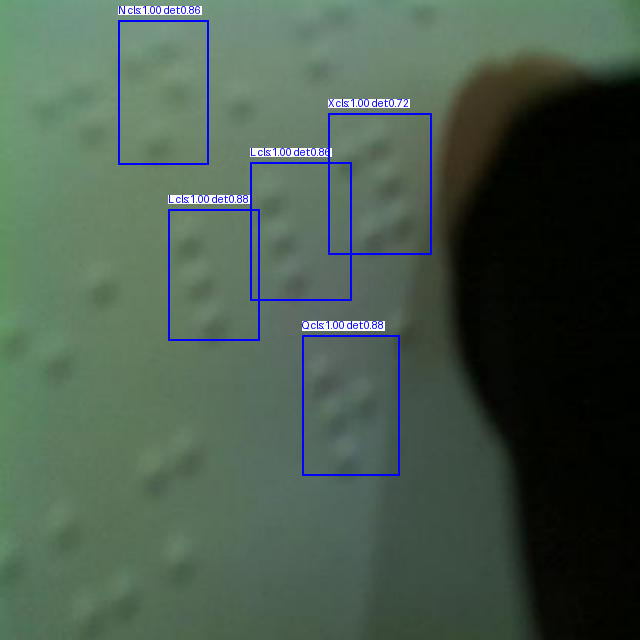

Saved: /content/outputs/yolo11_efficientnet_combined_images/1067_jpg.rf.710b2c5df9540f17b85bdf19c78dd2d6.jpg
1067_jpg.rf.a9efce29ee7be6a6dfd120af51fadf36.jpg detections: 5


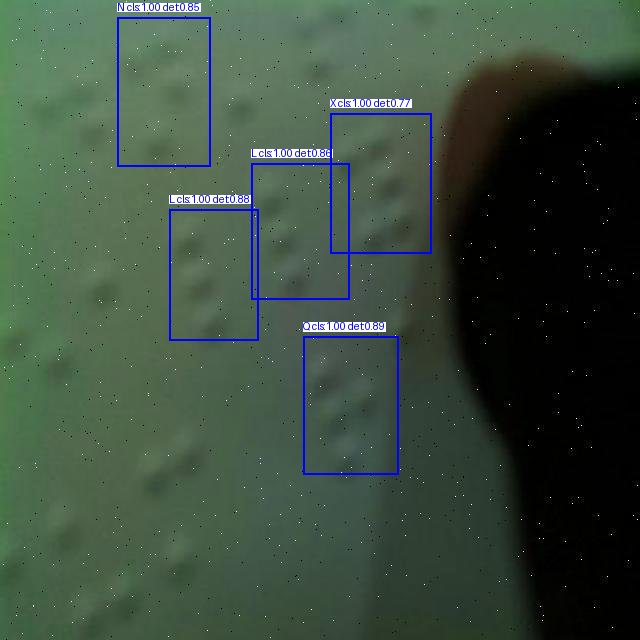

Saved: /content/outputs/yolo11_efficientnet_combined_images/1067_jpg.rf.a9efce29ee7be6a6dfd120af51fadf36.jpg
1070_jpg.rf.94158516fc379b6669a4411a231edace.jpg detections: 5


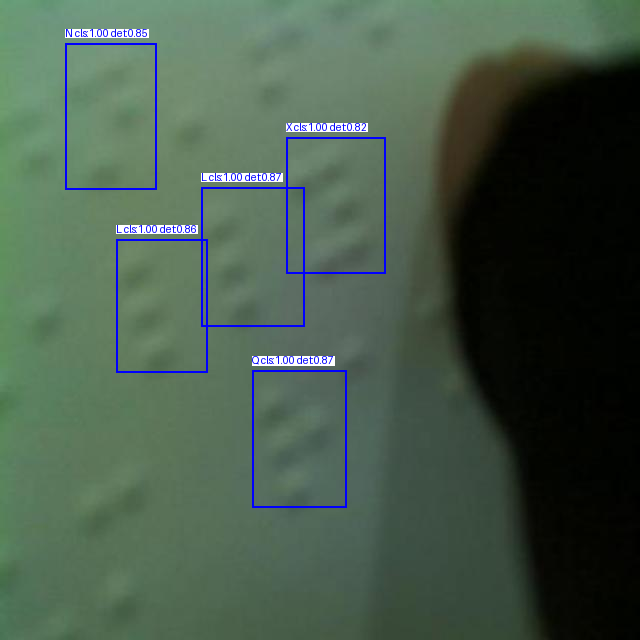

Saved: /content/outputs/yolo11_efficientnet_combined_images/1070_jpg.rf.94158516fc379b6669a4411a231edace.jpg
1072_jpg.rf.192db105e5a8fb643feeda2676372b2c.jpg detections: 5


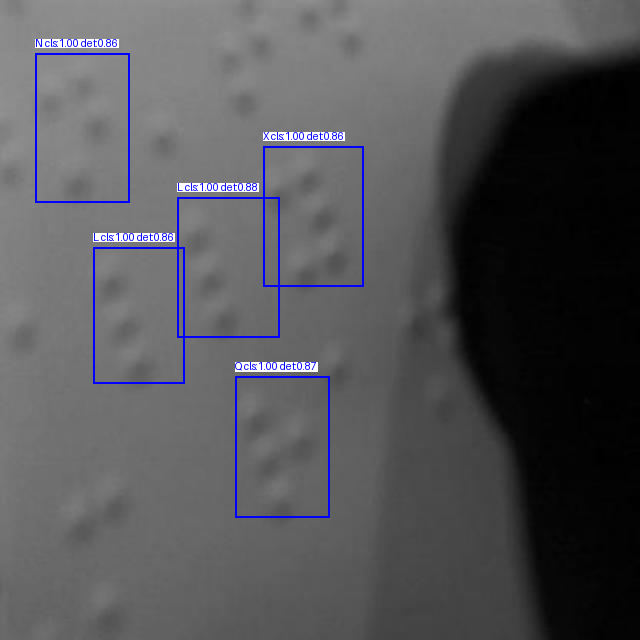

Saved: /content/outputs/yolo11_efficientnet_combined_images/1072_jpg.rf.192db105e5a8fb643feeda2676372b2c.jpg
1078_jpg.rf.629a4fdc2a8a64cf05580de51e7ac426.jpg detections: 6


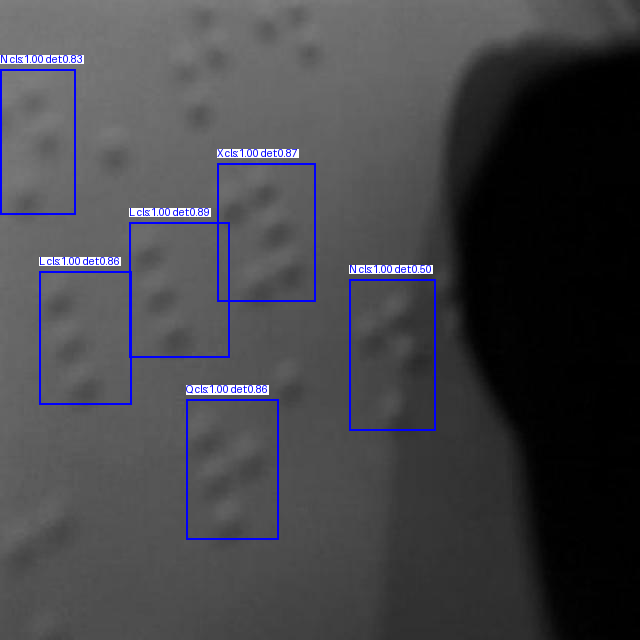

Saved: /content/outputs/yolo11_efficientnet_combined_images/1078_jpg.rf.629a4fdc2a8a64cf05580de51e7ac426.jpg


In [20]:
# 15. Test 이미지 5장에서 combined pipeline 시각화
# YOLO bounding box와 EfficientNet 예측 문자를 실제 이미지에 표시한다.

test_image_dir = (
    yolo_root / "images" / "test"
)
test_images = sorted(
    test_image_dir.glob("*.jpg")
)

print("Test images:", len(test_images))

for image_path in test_images[:5]:
    predictions, output_path = (
        run_combined_pipeline(
            image_path,
            detector_confidence=0.25,
            show_image=True,
        )
    )

    print("Saved:", output_path)

In [21]:
# 16. Combined pipeline end-to-end 평가를 위한 GT annotation 준비
# YOLO prediction과 정답 box를 IoU 0.50 기준으로 one-to-one matching한다.

test_coco_path = (
    coco_root
    / "annotations"
    / "instances_test2017.json"
)
test_coco = json.loads(
    test_coco_path.read_text()
)

test_category_names = {
    category["id"]: category["name"]
    for category in test_coco[
        "categories"
    ]
}
test_image_names = {
    image["id"]: image["file_name"]
    for image in test_coco["images"]
}

ground_truth_by_image = defaultdict(
    list
)

for annotation in test_coco[
    "annotations"
]:
    x, y, width, height = map(
        float,
        annotation["bbox"],
    )

    image_name = test_image_names[
        annotation["image_id"]
    ]

    ground_truth_by_image[
        image_name
    ].append({
        "box": np.array(
            [
                x,
                y,
                x + width,
                y + height,
            ],
            dtype=float,
        ),
        "label":
            test_category_names[
                annotation["category_id"]
            ],
    })


def calculate_box_iou(
    box_a,
    box_b,
):
    left = max(
        box_a[0],
        box_b[0],
    )
    top = max(
        box_a[1],
        box_b[1],
    )
    right = min(
        box_a[2],
        box_b[2],
    )
    bottom = min(
        box_a[3],
        box_b[3],
    )

    intersection = (
        max(0.0, right - left)
        * max(0.0, bottom - top)
    )

    area_a = (
        max(0.0, box_a[2] - box_a[0])
        * max(0.0, box_a[3] - box_a[1])
    )
    area_b = (
        max(0.0, box_b[2] - box_b[0])
        * max(0.0, box_b[3] - box_b[1])
    )

    union = (
        area_a + area_b - intersection
    )

    return (
        intersection / union
        if union > 0
        else 0.0
    )

In [22]:
# 17. 전체 Test set에서 YOLO11 + EfficientNet-B0 end-to-end 평가
# 올바르게 검출하고 분류한 문자 수를 기준으로 Precision, Recall과 F1을 계산한다.

ground_truth_total = 0
prediction_total = 0
matched_box_total = 0
correct_character_total = 0

prediction_stream = (
    best_detector.predict(
        source=str(test_image_dir),
        stream=True,
        imgsz=640,
        conf=0.25,
        iou=0.7,
        max_det=500,
        device=0,
        verbose=False,
    )
)

for result in prediction_stream:
    image_name = Path(
        result.path
    ).name

    true_items = (
        ground_truth_by_image[
            image_name
        ]
    )

    ground_truth_total += len(
        true_items
    )

    if result.boxes is None:
        predicted_boxes = np.empty(
            (0, 4)
        )
        predicted_scores = np.empty(0)
    else:
        predicted_boxes = (
            result.boxes.xyxy
            .cpu()
            .numpy()
        )
        predicted_scores = (
            result.boxes.conf
            .cpu()
            .numpy()
        )

    prediction_total += len(
        predicted_boxes
    )

    unmatched_true_indices = set(
        range(len(true_items))
    )
    matched_pairs = []

    for prediction_index in np.argsort(
        -predicted_scores
    ):
        if not unmatched_true_indices:
            break

        candidate_indices = list(
            unmatched_true_indices
        )

        candidate_ious = [
            calculate_box_iou(
                predicted_boxes[
                    prediction_index
                ],
                true_items[
                    true_index
                ]["box"],
            )
            for true_index
            in candidate_indices
        ]

        best_candidate_position = int(
            np.argmax(candidate_ious)
        )
        best_iou = candidate_ious[
            best_candidate_position
        ]

        if best_iou >= 0.50:
            true_index = (
                candidate_indices[
                    best_candidate_position
                ]
            )

            unmatched_true_indices.remove(
                true_index
            )
            matched_pairs.append(
                (
                    prediction_index,
                    true_index,
                )
            )

    matched_box_total += len(
        matched_pairs
    )

    if not matched_pairs:
        continue

    image = Image.open(
        result.path
    ).convert("RGB")

    matched_crop_tensors = [
        classifier_transform(
            crop_from_predicted_box(
                image,
                predicted_boxes[
                    prediction_index
                ],
            )
        )
        for prediction_index, _
        in matched_pairs
    ]

    with torch.no_grad():
        matched_predictions = (
            classifier(
                torch.stack(
                    matched_crop_tensors
                ).to(device)
            )
            .argmax(dim=1)
            .cpu()
            .tolist()
        )

    for (
        predicted_class_index,
        (_, true_index),
    ) in zip(
        matched_predictions,
        matched_pairs,
    ):
        predicted_letter = (
            idx_to_class[
                predicted_class_index
            ]
        )
        true_letter = true_items[
            true_index
        ]["label"]

        if predicted_letter == true_letter:
            correct_character_total += 1

In [23]:
# 18. 최종 YOLO11 + EfficientNet-B0 combined metrics 계산
# Ground-truth crop accuracy와 실제 end-to-end 결과를 구분해서 저장한다.

detector_precision_at_025 = (
    matched_box_total / prediction_total
    if prediction_total
    else 0.0
)
detector_recall_at_025 = (
    matched_box_total
    / ground_truth_total
    if ground_truth_total
    else 0.0
)
classification_accuracy_on_matched = (
    correct_character_total
    / matched_box_total
    if matched_box_total
    else 0.0
)
end_to_end_precision = (
    correct_character_total
    / prediction_total
    if prediction_total
    else 0.0
)
end_to_end_recall = (
    correct_character_total
    / ground_truth_total
    if ground_truth_total
    else 0.0
)
end_to_end_f1 = (
    2
    * end_to_end_precision
    * end_to_end_recall
    / (
        end_to_end_precision
        + end_to_end_recall
    )
    if (
        end_to_end_precision
        + end_to_end_recall
    )
    else 0.0
)

combined_metrics = {
    "yolo_epochs": 50,
    "efficientnet_epochs": 50,
    "detector_confidence_threshold":
        0.25,
    "matching_iou_threshold": 0.50,
    "ground_truth_characters":
        ground_truth_total,
    "predicted_boxes":
        prediction_total,
    "matched_boxes":
        matched_box_total,
    "correctly_detected_and_classified":
        correct_character_total,
    "detector_precision_at_0.25":
        detector_precision_at_025,
    "detector_recall_at_0.25":
        detector_recall_at_025,
    "classification_accuracy_on_matched_boxes":
        classification_accuracy_on_matched,
    "end_to_end_character_precision":
        end_to_end_precision,
    "end_to_end_character_recall":
        end_to_end_recall,
    "end_to_end_character_f1":
        end_to_end_f1,
}

combined_metrics_path = Path(
    "/content/outputs/"
    "yolo11_efficientnet_"
    "combined_metrics.json"
)
combined_metrics_path.write_text(
    json.dumps(
        combined_metrics,
        indent=2,
    )
)

print(
    json.dumps(
        combined_metrics,
        indent=2,
    )
)

print("\nPercentage Results")
print(
    "Detector precision:",
    f"{detector_precision_at_025 * 100:.2f}%",
)
print(
    "Detector recall:",
    f"{detector_recall_at_025 * 100:.2f}%",
)
print(
    "Classification accuracy on matched boxes:",
    f"{classification_accuracy_on_matched * 100:.2f}%",
)
print(
    "End-to-end precision:",
    f"{end_to_end_precision * 100:.2f}%",
)
print(
    "End-to-end recall:",
    f"{end_to_end_recall * 100:.2f}%",
)
print(
    "End-to-end F1:",
    f"{end_to_end_f1 * 100:.2f}%",
)

{
  "yolo_epochs": 50,
  "efficientnet_epochs": 50,
  "detector_confidence_threshold": 0.25,
  "matching_iou_threshold": 0.5,
  "ground_truth_characters": 10443,
  "predicted_boxes": 12720,
  "matched_boxes": 10250,
  "correctly_detected_and_classified": 10163,
  "detector_precision_at_0.25": 0.8058176100628931,
  "detector_recall_at_0.25": 0.9815187206741358,
  "classification_accuracy_on_matched_boxes": 0.9915121951219512,
  "end_to_end_character_precision": 0.7989779874213836,
  "end_to_end_character_recall": 0.9731877812889017,
  "end_to_end_character_f1": 0.8775201830505547
}

Percentage Results
Detector precision: 80.58%
Detector recall: 98.15%
Classification accuracy on matched boxes: 99.15%
End-to-end precision: 79.90%
End-to-end recall: 97.32%
End-to-end F1: 87.75%


In [24]:
# 19. YOLO11, EfficientNet-B0와 combined 결과를 ZIP으로 압축
# Dataset은 제외하고 모델, metrics, 그래프와 예측 이미지만 저장한다.

import shutil

from google.colab import files

result_bundle_dir = Path(
    "/content/"
    "yolo11_efficientnet_"
    "50epochs_results"
)
result_bundle_dir.mkdir(
    parents=True,
    exist_ok=True,
)

shutil.copytree(
    yolo_project_dir,
    result_bundle_dir
    / "yolo11_detector",
    dirs_exist_ok=True,
)

shutil.copytree(
    classification_output_dir,
    result_bundle_dir
    / "efficientnet_b0_classifier",
    dirs_exist_ok=True,
)

shutil.copytree(
    combined_output_dir,
    result_bundle_dir
    / "combined_prediction_images",
    dirs_exist_ok=True,
)

if combined_metrics_path.exists():
    shutil.copy2(
        combined_metrics_path,
        result_bundle_dir
        / combined_metrics_path.name,
    )

result_archive_path = (
    shutil.make_archive(
        str(result_bundle_dir),
        "zip",
        root_dir=result_bundle_dir,
    )
)

print(
    "Created:",
    result_archive_path,
)
print(
    "Archive size:",
    round(
        Path(
            result_archive_path
        ).stat().st_size
        / 1024**2,
        1,
    ),
    "MB",
)

Created: /content/yolo11_efficientnet_50epochs_results.zip
Archive size: 357.0 MB


In [25]:
# 20. 최종 결과 ZIP 파일을 로컬 컴퓨터로 다운로드
# 다운로드한 ZIP을 ai4all 폴더에 넣으면 결과를 다시 분석할 수 있다.

from google.colab import files

files.download(
    result_archive_path
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>